Dataset shape: (891, 12)

First 5 rows:
    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0      

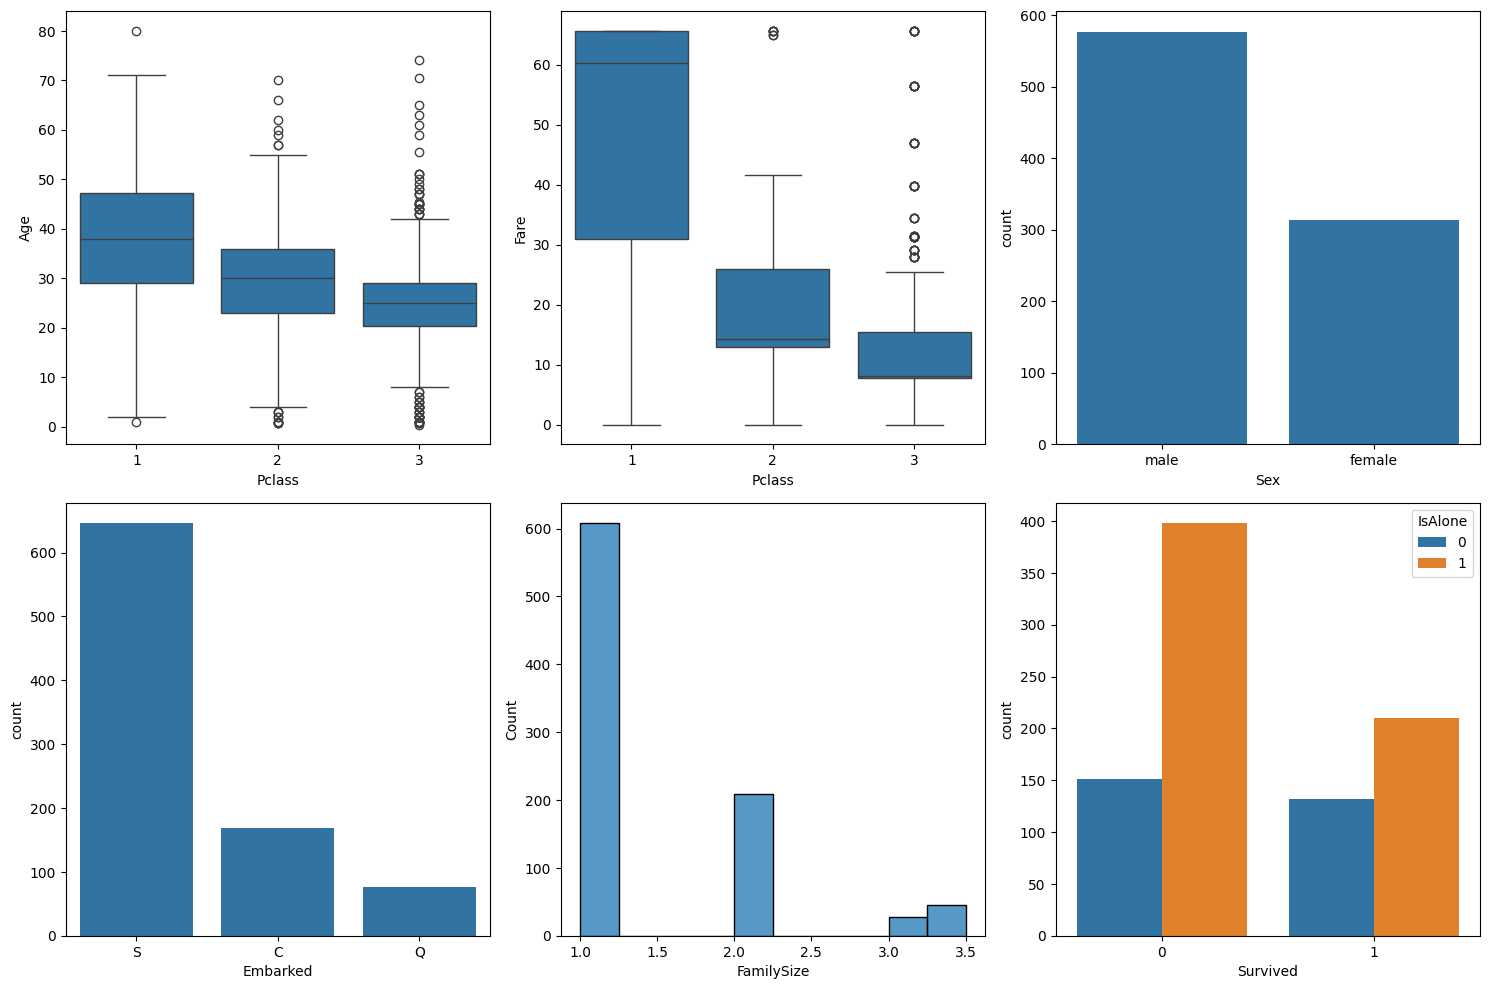

In [2]:
# Data Science Lab Assignment 1: Dataset Exploration & Preprocessing
# Dataset: Kaggle Titanic (train.csv) [web:162]

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Step 1: Load dataset
df = pd.read_csv('train.csv')  # Download from Kaggle Titanic competition
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

# Step 2: Explore structure and identify features
print("\nDataset info:")
print(df.info())
print("\nDescriptive statistics (numeric):\n", df.describe())

# Categorical value counts
print("\nSex distribution:\n", df['Sex'].value_counts())
print("Pclass distribution:\n", df['Pclass'].value_counts())
print("Embarked distribution:\n", df['Embarked'].value_counts())

# Step 3: Handle MISSING VALUES
# Age: Fill with median by Pclass + Sex group and Embarked: Fill with mode
df['Age'] = df['Age'].fillna(
    df.groupby(['Pclass', 'Sex'])['Age'].transform('median')
)

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
# Cabin: Drop (80% missing) - too noisy
df.drop('Cabin', axis=1, inplace=True)
print("\nMissing values after treatment:\n", df.isnull().sum())

# Step 4: Detect and treat OUTLIERS (IQR method on Fare, SibSp, Parch)
def treat_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    series = np.clip(series, lower, upper)
    return series

df['Fare'] = treat_outliers(df['Fare'])
df['SibSp'] = treat_outliers(df['SibSp'])
df['Parch'] = treat_outliers(df['Parch'])

# Step 5: Handle NOISE (categorical cleaning + feature engineering)
# Standardize Sex, Embarked to lowercase + create features
df['Sex'] = df['Sex'].str.lower()
df['Embarked'] = df['Embarked'].str.upper()
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # Total family including self
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Drop irrelevant columns
df_clean = df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)

print("\nCleaned dataset shape:", df_clean.shape)
print("\nFinal descriptive stats:\n", df_clean.describe())
print("\nSample of cleaned data:\n", df_clean.head())

# Step 6: Visualize changes
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
sns.boxplot(data=df_clean, x='Pclass', y='Age', ax=axes[0,0])
sns.boxplot(data=df_clean, x='Pclass', y='Fare', ax=axes[0,1])
sns.countplot(data=df_clean, x='Sex', ax=axes[0,2])
sns.countplot(data=df_clean, x='Embarked', ax=axes[1,0])
sns.histplot(data=df_clean, x='FamilySize', bins=10, ax=axes[1,1])
sns.countplot(data=df_clean, x='Survived', hue='IsAlone', ax=axes[1,2])
plt.tight_layout()
plt.show()
